## **Messwerte**

In [29]:
import numpy as np

#Konstanten

l = 29.2e-2 #Höhendifferenz in m
l_Fehler = 1e-3

g = 9.81 #Erdbeschleunigung in m/s**2

rho_K = 7850 #Dichte der Kugel in kg/m**3
rho_K_Fehler = 0

rho_Fl = 0.86*1000 #Dichte der Flüssigkeit in kg/m**3
rho_Fl_Fehler = 0

R = 5.8e-2 #Zylinderradius in m
R_fehler = 1e-3

#Messungen

r = np.array([2, 3, 4, 5]) * 10**(-3)/2 #Kugelradius in m
r_Fehler = np.ones(4) * 0.01e-3

t = np.array([[40.93, 40.94, 40.83, 40.70], #Fallzeit für r = 1mm    in s

              [18.36, 18.68, 18.69, 18.76], # r = 1,5mm

              [10.99, 10.86, 11.04, 10.91], # r = 2mm

              [7.42, 7.50, 7.23, 7.31]  # r = 2.5mm

              ])

Mittelwerte = t.mean(axis = 1)
t_Fehler = np.ones(4) * 500 * 10**(-3)

## **Lineare Regression**

Text(0.5, 1.0, 'Fallzeiten')

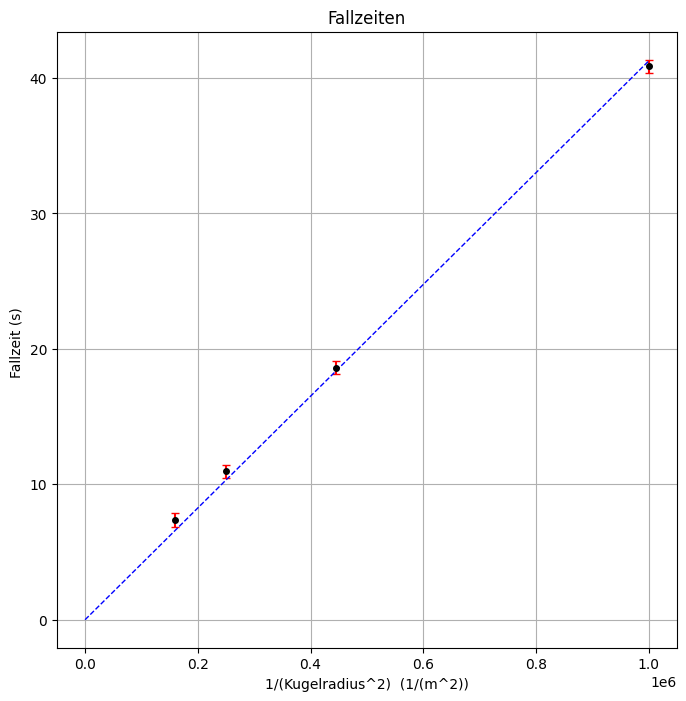

In [30]:
import scipy
import matplotlib.pyplot as plt

#Fit Funktion
def f(x, k):
    return k*x

coefficients , pcov = scipy.optimize.curve_fit(f, 1/(r**2), Mittelwerte, sigma = t_Fehler, absolute_sigma = True)

k = coefficients[0]
k_Fehler = np.sqrt(pcov[0,0])


#Plots
fig, ax1 = plt.subplots(1,1, figsize = (8,8))

ax1.errorbar(1/(r**2), Mittelwerte, yerr = t_Fehler , fmt = "o", label = "Datensatz", color = "black", markersize  = 4 , capsize = 3, ecolor = "r")
xvalues = np.linspace(0, np.max(1/(r**2))+0.01, num = 100)
ax1.plot(xvalues, k * xvalues  , "--", color = "blue", linewidth = 1)

ax1.set_xlabel("1/(Kugelradius^2)  (1/(m^2))")
ax1.set_ylabel("Fallzeit (s) ")

ax1.grid(True)
ax1.set_title("Fallzeiten")

## **Fehlerbetrachtung und Ergebnis**

In [31]:
import sympy as sp
from Skripte.Fehlerfortpflanzung import Gaußfehler
from IPython.display import display

kp, rhok, rhofl, lp = sp.symbols("k, rho_k, rho_fl, l")

expr = (kp * 2 * g * (rhok - rhofl)) / (lp*9)
display(expr)

Variablen = np.array([kp, rhok, rhofl, lp])
Werte = np.array([k, rho_K, rho_Fl, l])
Fehler = np.array([k_Fehler, rho_K_Fehler, rho_Fl_Fehler, l_Fehler])

eta = (2*k*g*(rho_K-rho_Fl)) / (l*9)
eta_Fehler = Gaußfehler(expr, Variablen, Werte, Fehler)

print("\u03B7", f"= {eta} +/- {eta_Fehler} Pa*s")
print(" 2.153 +/- 0.025" )

2.18*k*(-rho_fl + rho_k)/l

η = 2.153074506907146 +/- 0.024164882538039334 Pa*s
 2.153 +/- 0.025


## **Untersuchung Ladenburg Korrektur**

η = 2.0669077988840265 Pa*s


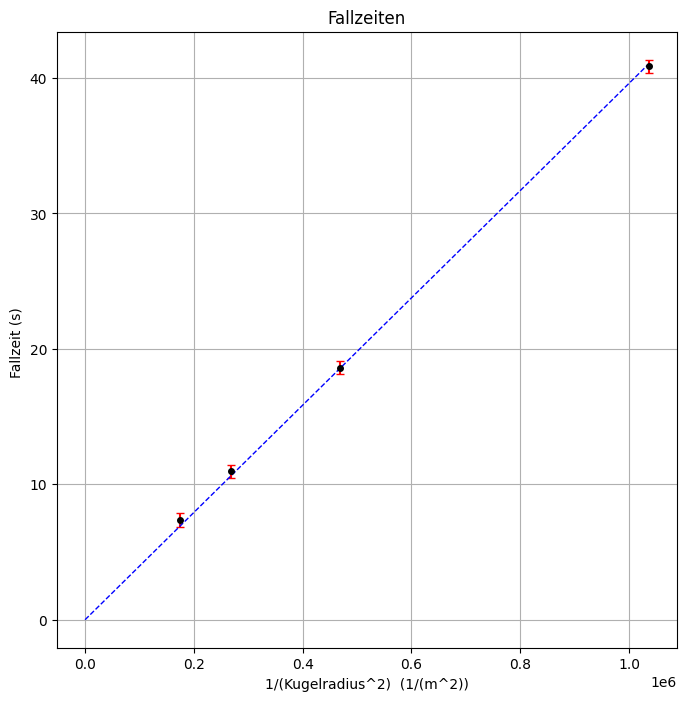

In [36]:

lmbda = 1 + 2.1*(r/R)

coefficients , pcov = scipy.optimize.curve_fit(f, lmbda/(r**2), Mittelwerte, sigma = t_Fehler, absolute_sigma = True)

k = coefficients[0]
k_Fehler = np.sqrt(pcov[0,0])

#Plots
fig, ax2 = plt.subplots(1,1, figsize = (8,8))

ax2.errorbar(lmbda/(r**2), Mittelwerte, yerr = t_Fehler , fmt = "o", label = "Datensatz", color = "black", markersize  = 4 , capsize = 3, ecolor = "r")
xvalues = np.linspace(0, np.max(lmbda/(r**2))+0.5, num = 100)
ax2.plot(xvalues, k * xvalues  , "--", color = "blue", linewidth = 1)

ax2.set_xlabel("1/(Kugelradius^2)  (1/(m^2))")
ax2.set_ylabel("Fallzeit (s) ")

ax2.grid(True)
ax2.set_title("Fallzeiten")

eta_korr = (2*k*g*(rho_K-rho_Fl)) / (l*9)

print("\u03B7", f"= {eta_korr} Pa*s")